# Spatial VQ-VAE Variant (DeMemte)

Variante basada en **Spatial ConvVAE**, reemplazando el bloque variacional continuo por **VQ-VAE espacial** con codebook EMA.

Objetivos:
- Usar `d_q = ||z_e - z_q||^2` como señal de familiaridad.
- Hacer compuerta por muestra (no por batch global) para estabilidad.
- Entrenar en **feature-space denoising**: `input=noisy_feats`, `target=clean_feats`.

## 1) Environment Setup and Imports

In [1]:
# Si falta algo, descomenta:
# !pip install torch torchvision matplotlib scikit-learn

import os
import copy
import json
import random
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset

import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedKFold

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda:', torch.cuda.is_available())

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
cuda: True


## 2) Project Configuration and Constants

In [2]:
@dataclass
class Config:
    data_dir: str = '../data'
    num_classes: int = 102
    batch_size: int = 64
    num_workers: int = 2

    # Entrenamiento base
    epochs_phase1: int = 5
    epochs_phase2: int = 8
    lr_vq: float = 3e-4
    lr_cls: float = 1e-3
    weight_decay: float = 1e-4

    # Ruido en feature-space (Option B)
    feature_noise_std: float = 0.35

    # VQ-VAE
    embedding_dim: int = 128
    num_embeddings: int = 512
    commitment_cost: float = 0.25
    ema_decay: float = 0.99
    eps: float = 1e-5

    # Gate por familiaridad
    init_tau: float = 0.0
    init_alpha: float = 1.5
    init_memory_scale: float = 1.0

    # Pérdidas
    denoise_weight: float = 1.0
    vq_weight: float = 1.0

    # Cross-validation / anti-overfit
    n_splits: int = 3
    cv_seed: int = 42
    early_stop_patience_p1: int = 2
    early_stop_patience_p2: int = 3
    early_stop_min_delta: float = 1e-4
    scheduler_factor: float = 0.5
    scheduler_patience: int = 1

    # Artefactos
    artifacts_root: str = './out/artifacts'
    experiment_name: str = 'spatial_vqvae_cv'

    # Debug
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    max_train_batches_debug: int = 20
    max_val_batches_debug: int = 10

cfg = Config()
print(json.dumps(asdict(cfg), indent=2))

{
  "data_dir": "../data",
  "num_classes": 102,
  "batch_size": 64,
  "num_workers": 2,
  "epochs_phase1": 5,
  "epochs_phase2": 8,
  "lr_vq": 0.0003,
  "lr_cls": 0.001,
  "weight_decay": 0.0001,
  "feature_noise_std": 0.35,
  "embedding_dim": 128,
  "num_embeddings": 512,
  "commitment_cost": 0.25,
  "ema_decay": 0.99,
  "eps": 1e-05,
  "init_tau": 0.0,
  "init_alpha": 1.5,
  "init_memory_scale": 1.0,
  "denoise_weight": 1.0,
  "vq_weight": 1.0,
  "n_splits": 3,
  "cv_seed": 42,
  "early_stop_patience_p1": 2,
  "early_stop_patience_p2": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 1,
  "artifacts_root": "./out/artifacts",
  "experiment_name": "spatial_vqvae_cv",
  "device": "cuda",
  "max_train_batches_debug": 20,
  "max_val_batches_debug": 10
}


## 3) Input Loading and Preprocessing

In [3]:
def _extract_labels(dataset):
    if hasattr(dataset, '_labels'):
        return np.array(dataset._labels)
    if hasattr(dataset, 'labels'):
        return np.array(dataset.labels)

    labels = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        labels.append(int(y))
    return np.array(labels)


def build_datasets(config: Config):
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    trainset = torchvision.datasets.Flowers102(root=config.data_dir, split='train', download=False, transform=transform_train)
    valset = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=False, transform=transform_eval)
    testset = torchvision.datasets.Flowers102(root=config.data_dir, split='test', download=False, transform=transform_eval)

    cv_dataset = ConcatDataset([trainset, valset])
    cv_labels = np.concatenate([_extract_labels(trainset), _extract_labels(valset)], axis=0)

    testloader = DataLoader(testset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    return cv_dataset, cv_labels, testset, testloader


cv_dataset, cv_labels, testset, testloader = build_datasets(cfg)
print('cv size:', len(cv_dataset), '| classes:', len(np.unique(cv_labels)))
xb, yb = next(iter(testloader))
print('test batch x:', tuple(xb.shape), 'batch y:', tuple(yb.shape))

cv size: 2040 | classes: 102
test batch x: (64, 3, 224, 224) batch y: (64,)


## 4) Core Function/Class Implementation

In [4]:
def make_spatial_backbone():
    """ResNet18 truncado para obtener feature map [B, 512, 7, 7]."""
    base = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    body = list(base.children())[:-2]
    return nn.Sequential(*body)


class VectorQuantizerEMA(nn.Module):
    """Vector Quantization con codebook EMA para evitar collapse."""
    def __init__(self, num_embeddings: int, embedding_dim: int, commitment_cost: float = 0.25,
                 decay: float = 0.99, eps: float = 1e-5):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.eps = eps

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

        self.register_buffer('ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer('ema_w', self.embedding.weight.data.clone())

    def forward(self, z_e: torch.Tensor):
        # z_e: [B, C, H, W], C=embedding_dim
        b, c, h, w = z_e.shape
        assert c == self.embedding_dim

        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()      # [B,H,W,C]
        flat = z_e_perm.view(-1, c)                           # [N,C]

        emb = self.embedding.weight                           # [K,C]
        distances = (
            flat.pow(2).sum(dim=1, keepdim=True)
            - 2 * flat @ emb.t()
            + emb.pow(2).sum(dim=1, keepdim=True).t()
        )

        encoding_indices = torch.argmin(distances, dim=1)     # [N]
        encodings = F.one_hot(encoding_indices, self.num_embeddings).type(flat.dtype)

        quantized_flat = encodings @ emb                       # [N,C]
        quantized = quantized_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()

        if self.training:
            n = encodings.sum(dim=0)
            dw = encodings.t() @ flat

            self.ema_cluster_size.mul_(self.decay).add_(n, alpha=1 - self.decay)
            self.ema_w.mul_(self.decay).add_(dw, alpha=1 - self.decay)

            total = self.ema_cluster_size.sum()
            cluster_size = (
                (self.ema_cluster_size + self.eps)
                / (total + self.num_embeddings * self.eps)
                * total
            )
            normalized_embed = self.ema_w / cluster_size.unsqueeze(1)
            self.embedding.weight.data.copy_(normalized_embed)

        commitment_loss = self.commitment_cost * F.mse_loss(z_e, quantized.detach())
        quantized_st = z_e + (quantized - z_e).detach()       # STE

        avg_probs = encodings.float().mean(dim=0)
        perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum())

        # señal directa de familiaridad: d_q = ||z_e - z_q||^2
        dq_map = ((z_e - quantized.detach()) ** 2).mean(dim=1, keepdim=True)

        code_map = encoding_indices.view(b, h, w)
        return quantized_st, commitment_loss, dq_map, perplexity, code_map


class SpatialVQVAE(nn.Module):
    """VQ-VAE espacial: entrada/salida [B,512,7,7]."""
    def __init__(self, in_channels=512, hidden_channels=256, embedding_dim=128,
                 num_embeddings=512, commitment_cost=0.25, decay=0.99, eps=1e-5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1),
        )

        self.vq = VectorQuantizerEMA(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
            commitment_cost=commitment_cost,
            decay=decay,
            eps=eps,
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(embedding_dim, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, kernel_size=1),
        )

    def forward(self, x: torch.Tensor):
        z_e = self.encoder(x)
        z_q, vq_loss, dq_map, perplexity, code_map = self.vq(z_e)
        x_rec = self.decoder(z_q)
        return x_rec, vq_loss, dq_map, perplexity, code_map


class DeMemte_SpatialVQ(nn.Module):
    """
    Variante DeMemte con VQ-VAE espacial.
    - Denoising en feature-space (Option B): input=noisy_feats, target=clean_feats
    - Gate por familiaridad usando d_q normalizado por muestra.
    """
    def __init__(self, backbone: nn.Module, vq_vae: SpatialVQVAE, num_classes: int):
        super().__init__()
        self.backbone = backbone
        self.vq_vae = vq_vae

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.feat_norm = nn.LayerNorm(512)
        self.classifier = nn.Linear(512, num_classes)

        self.gate_tau = nn.Parameter(torch.tensor(0.0))
        self.gate_alpha = nn.Parameter(torch.tensor(1.5))
        self.memory_scale = nn.Parameter(torch.tensor(1.0))

    def _extract_backbone(self, x: torch.Tensor):
        with torch.no_grad():
            return self.backbone(x)

    @staticmethod
    def _normalize_per_sample(dq_map: torch.Tensor, eps: float = 1e-6):
        # Normaliza cada muestra de forma independiente sobre (C,H,W) actuales.
        mean = dq_map.mean(dim=(1, 2, 3), keepdim=True)
        std = dq_map.std(dim=(1, 2, 3), keepdim=True)
        return (dq_map - mean) / (std + eps)

    def forward(self, x: torch.Tensor, feature_noise_std: float = 0.0, return_debug: bool = False):
        clean_feats = self._extract_backbone(x)                        # target limpio

        if feature_noise_std > 0:
            noisy_feats = clean_feats + feature_noise_std * torch.randn_like(clean_feats)
        else:
            noisy_feats = clean_feats

        rec_feats, vq_loss, dq_map, perplexity, code_map = self.vq_vae(noisy_feats)
        denoise_loss = F.mse_loss(rec_feats, clean_feats)

        dq_norm = self._normalize_per_sample(dq_map)
        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (self.gate_tau - dq_norm))

        enhanced_spatial = noisy_feats + self.memory_scale * signal * rec_feats

        features = self.feat_norm(self.pool(noisy_feats).flatten(1))
        enhanced = self.feat_norm(self.pool(enhanced_spatial).flatten(1))
        logits = self.classifier(enhanced)

        if return_debug:
            debug = {
                'clean_feats': clean_feats,
                'noisy_feats': noisy_feats,
                'rec_feats': rec_feats,
                'dq_map': dq_map,
                'dq_norm': dq_norm,
                'signal': signal,
                'perplexity': perplexity,
                'code_map': code_map,
                'features': features,
                'enhanced': enhanced,
            }
            return logits, denoise_loss, vq_loss, debug

        return logits, denoise_loss, vq_loss

## 5) Pipeline Execution

In [5]:
device = torch.device(cfg.device)
criterion = nn.CrossEntropyLoss()


def make_model_and_optimizers(config: Config):
    backbone = make_spatial_backbone().to(device)
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()

    vq_vae = SpatialVQVAE(
        in_channels=512,
        hidden_channels=256,
        embedding_dim=config.embedding_dim,
        num_embeddings=config.num_embeddings,
        commitment_cost=config.commitment_cost,
        decay=config.ema_decay,
        eps=config.eps,
    ).to(device)

    model = DeMemte_SpatialVQ(backbone=backbone, vq_vae=vq_vae, num_classes=config.num_classes).to(device)
    model.gate_tau.data.fill_(config.init_tau)
    model.gate_alpha.data.fill_(config.init_alpha)
    model.memory_scale.data.fill_(config.init_memory_scale)

    phase1_params = list(model.vq_vae.parameters()) + [model.gate_tau, model.gate_alpha, model.memory_scale]
    opt_p1 = optim.AdamW(phase1_params, lr=config.lr_vq, weight_decay=config.weight_decay)
    sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(
        opt_p1, mode='min', factor=config.scheduler_factor, patience=config.scheduler_patience
    )

    opt_p2 = optim.AdamW([
        {'params': model.vq_vae.parameters(), 'lr': config.lr_vq},
        {'params': model.classifier.parameters(), 'lr': config.lr_cls},
        {'params': [model.gate_tau, model.gate_alpha, model.memory_scale], 'lr': config.lr_vq},
    ], weight_decay=config.weight_decay)
    sch_p2 = optim.lr_scheduler.ReduceLROnPlateau(
        opt_p2, mode='min', factor=config.scheduler_factor, patience=config.scheduler_patience
    )

    return model, opt_p1, sch_p1, opt_p2, sch_p2


def run_epoch_phase1(model, loader, optimizer, config: Config, train: bool):
    model.train(train)
    total = {'loss': 0.0, 'denoise': 0.0, 'vq': 0.0, 'perplexity': 0.0, 'n': 0}

    for bi, (x, _) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if not train and bi >= config.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        _, denoise_loss, vq_loss, debug = model(
            x,
            feature_noise_std=config.feature_noise_std,
            return_debug=True,
        )
        loss = config.denoise_weight * denoise_loss + config.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        total['loss'] += loss.item() * bs
        total['denoise'] += denoise_loss.item() * bs
        total['vq'] += vq_loss.item() * bs
        total['perplexity'] += float(debug['perplexity'].item()) * bs
        total['n'] += bs

    for k in ['loss', 'denoise', 'vq', 'perplexity']:
        total[k] /= max(1, total['n'])
    return total


def run_epoch_phase2(model, loader, optimizer, config: Config, train: bool):
    model.train(train)
    total = {'loss': 0.0, 'ce': 0.0, 'denoise': 0.0, 'vq': 0.0, 'acc': 0.0, 'n': 0}

    for bi, (x, y) in enumerate(loader):
        if train and bi >= config.max_train_batches_debug:
            break
        if not train and bi >= config.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits, denoise_loss, vq_loss = model(x, feature_noise_std=config.feature_noise_std)
        ce_loss = criterion(logits, y)
        loss = ce_loss + config.denoise_weight * denoise_loss + config.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        pred = logits.argmax(dim=1)
        acc = (pred == y).float().mean().item()

        total['loss'] += loss.item() * bs
        total['ce'] += ce_loss.item() * bs
        total['denoise'] += denoise_loss.item() * bs
        total['vq'] += vq_loss.item() * bs
        total['acc'] += acc * bs
        total['n'] += bs

    for k in ['loss', 'ce', 'denoise', 'vq', 'acc']:
        total[k] /= max(1, total['n'])
    return total


def evaluate_loader(model, loader, max_batches=None):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits, _, _ = model(x, feature_noise_std=0.0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / max(1, total)


run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
artifacts_dir = os.path.join(cfg.artifacts_root, f"{cfg.experiment_name}_{run_stamp}")
os.makedirs(artifacts_dir, exist_ok=True)

skf = StratifiedKFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.cv_seed)
fold_results = []
best_fold = None
best_fold_acc = -1.0
best_model_state = None

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(cv_labels)), cv_labels), start=1):
    print(f"\n===== Fold {fold_idx}/{cfg.n_splits} =====")

    fold_train_ds = Subset(cv_dataset, train_idx.tolist())
    fold_val_ds = Subset(cv_dataset, val_idx.tolist())

    fold_train_loader = DataLoader(
        fold_train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )
    fold_val_loader = DataLoader(
        fold_val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )

    model, opt_p1, sch_p1, opt_p2, sch_p2 = make_model_and_optimizers(cfg)

    fold_history = {'p1_train': [], 'p1_val': [], 'p2_train': [], 'p2_val': []}

    best_p1_loss = float('inf')
    best_p1_state = copy.deepcopy(model.state_dict())
    no_improve_p1 = 0

    for ep in range(1, cfg.epochs_phase1 + 1):
        tr = run_epoch_phase1(model, fold_train_loader, opt_p1, cfg, train=True)
        va = run_epoch_phase1(model, fold_val_loader, opt_p1, cfg, train=False)
        sch_p1.step(va['loss'])

        fold_history['p1_train'].append(tr)
        fold_history['p1_val'].append(va)

        print(f"[Fold {fold_idx} | P1 {ep:02d}] loss={tr['loss']:.4f} val_loss={va['loss']:.4f} perplexity={tr['perplexity']:.1f}")

        if va['loss'] < best_p1_loss - cfg.early_stop_min_delta:
            best_p1_loss = va['loss']
            best_p1_state = copy.deepcopy(model.state_dict())
            no_improve_p1 = 0
        else:
            no_improve_p1 += 1
            if no_improve_p1 >= cfg.early_stop_patience_p1:
                print(f"Early stop P1 en época {ep} (fold {fold_idx}).")
                break

    model.load_state_dict(best_p1_state)

    best_p2_acc = -1.0
    best_p2_state = copy.deepcopy(model.state_dict())
    no_improve_p2 = 0

    for ep in range(1, cfg.epochs_phase2 + 1):
        tr = run_epoch_phase2(model, fold_train_loader, opt_p2, cfg, train=True)
        va = run_epoch_phase2(model, fold_val_loader, opt_p2, cfg, train=False)
        sch_p2.step(va['loss'])

        fold_history['p2_train'].append(tr)
        fold_history['p2_val'].append(va)

        print(f"[Fold {fold_idx} | P2 {ep:02d}] loss={tr['loss']:.4f} acc={tr['acc']:.4f} | val_loss={va['loss']:.4f} val_acc={va['acc']:.4f}")

        if va['acc'] > best_p2_acc + cfg.early_stop_min_delta:
            best_p2_acc = va['acc']
            best_p2_state = copy.deepcopy(model.state_dict())
            no_improve_p2 = 0
        else:
            no_improve_p2 += 1
            if no_improve_p2 >= cfg.early_stop_patience_p2:
                print(f"Early stop P2 en época {ep} (fold {fold_idx}).")
                break

    model.load_state_dict(best_p2_state)

    fold_val_acc = evaluate_loader(model, fold_val_loader, max_batches=cfg.max_val_batches_debug)
    fold_test_acc = evaluate_loader(model, testloader, max_batches=cfg.max_val_batches_debug)

    fold_ckpt_path = os.path.join(artifacts_dir, f'fold_{fold_idx}_best.pt')
    torch.save({
        'fold': fold_idx,
        'config': asdict(cfg),
        'best_p1_val_loss': best_p1_loss,
        'best_p2_val_acc': best_p2_acc,
        'fold_val_acc': fold_val_acc,
        'fold_test_acc_debug': fold_test_acc,
        'model_state': best_p2_state,
    }, fold_ckpt_path)

    fold_result = {
        'fold': fold_idx,
        'val_acc': float(fold_val_acc),
        'test_acc_debug': float(fold_test_acc),
        'best_p1_val_loss': float(best_p1_loss),
        'best_p2_val_acc': float(best_p2_acc),
        'checkpoint_path': fold_ckpt_path,
        'history': fold_history,
    }
    fold_results.append(fold_result)

    print(f"[Fold {fold_idx}] val_acc={fold_val_acc:.4f} test_acc(debug)={fold_test_acc:.4f}")
    print(f"Checkpoint fold guardado en: {fold_ckpt_path}")

    if fold_val_acc > best_fold_acc:
        best_fold_acc = fold_val_acc
        best_fold = fold_idx
        best_model_state = copy.deepcopy(model.state_dict())

        trainloader = fold_train_loader
        valloader = fold_val_loader

model, _, _, _, _ = make_model_and_optimizers(cfg)
model.load_state_dict(best_model_state)

best_ckpt_path = os.path.join(artifacts_dir, 'best_model.pt')
torch.save({
    'best_fold': best_fold,
    'best_fold_acc': float(best_fold_acc),
    'config': asdict(cfg),
    'model_state': best_model_state,
}, best_ckpt_path)

cv_val_scores = [fr['val_acc'] for fr in fold_results]
history = {
    'cv': fold_results,
    'best_fold': best_fold,
    'cv_val_mean': float(np.mean(cv_val_scores)),
    'cv_val_std': float(np.std(cv_val_scores)),
    'artifacts_dir': artifacts_dir,
    'best_checkpoint': best_ckpt_path,
}

metrics_json_path = os.path.join(artifacts_dir, 'cv_metrics.json')
with open(metrics_json_path, 'w', encoding='utf-8') as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print('\n===== CV Summary =====')
print('best_fold:', best_fold)
print('cv_val_mean:', history['cv_val_mean'])
print('cv_val_std:', history['cv_val_std'])
print('artifacts_dir:', artifacts_dir)
print('best_checkpoint:', best_ckpt_path)
print('metrics_json:', metrics_json_path)


===== Fold 1/3 =====
[Fold 1 | P1 01] loss=2.3030 val_loss=1.8280 perplexity=55.1
[Fold 1 | P1 02] loss=1.8028 val_loss=1.7470 perplexity=67.7
[Fold 1 | P1 03] loss=1.7038 val_loss=1.7297 perplexity=75.6
[Fold 1 | P1 04] loss=1.6736 val_loss=1.6845 perplexity=79.7
[Fold 1 | P1 05] loss=1.6534 val_loss=1.6843 perplexity=87.0
[Fold 1 | P2 01] loss=5.7638 acc=0.1391 | val_loss=4.9434 val_acc=0.4031
[Fold 1 | P2 02] loss=4.0757 acc=0.6820 | val_loss=3.8872 val_acc=0.6750
[Fold 1 | P2 03] loss=3.0858 acc=0.8703 | val_loss=3.2865 val_acc=0.7609
[Fold 1 | P2 04] loss=2.5698 acc=0.9359 | val_loss=2.9744 val_acc=0.8094
[Fold 1 | P2 05] loss=2.2732 acc=0.9641 | val_loss=2.7648 val_acc=0.8328
[Fold 1 | P2 06] loss=2.0955 acc=0.9797 | val_loss=2.6820 val_acc=0.8281
[Fold 1 | P2 07] loss=1.9936 acc=0.9883 | val_loss=2.5807 val_acc=0.8406
[Fold 1 | P2 08] loss=1.9120 acc=0.9922 | val_loss=2.5187 val_acc=0.8500
[Fold 1] val_acc=0.8406 test_acc(debug)=0.8469
Checkpoint fold guardado en: ./out/artifac

## 6) Basic Validation and Unit Tests

In [6]:
model.eval()
with torch.no_grad():
    x, y = next(iter(valloader))
    x = x[:8].to(device)
    logits, denoise_loss, vq_loss, dbg = model(x, feature_noise_std=cfg.feature_noise_std, return_debug=True)

assert logits.shape == (8, cfg.num_classes), f'logits shape inválida: {tuple(logits.shape)}'
assert dbg['dq_map'].shape == (8, 1, 7, 7), f'dq_map shape inválida: {tuple(dbg["dq_map"].shape)}'
assert dbg['signal'].shape == (8, 1, 7, 7), f'signal shape inválida: {tuple(dbg["signal"].shape)}'
assert torch.isfinite(denoise_loss), 'denoise_loss no finita'
assert torch.isfinite(vq_loss), 'vq_loss no finita'
assert dbg['signal'].min().item() >= 0.0 and dbg['signal'].max().item() <= 1.0, 'signal fuera de [0,1]'
print('✅ Shapes y rangos válidos.')
print('denoise_loss:', denoise_loss.item(), '| vq_loss:', vq_loss.item(), '| perplexity:', float(dbg['perplexity'].item()))

✅ Shapes y rangos válidos.
denoise_loss: 1.498761534690857 | vq_loss: 0.13356497883796692 | perplexity: 32.952781677246094


## 7) Output Inspection and Debug Logging

=== Gaussian noise sweep (MC) ===
noise_std=0.35: clean=0.8469±0.0000 | noisy=0.8509±0.0040
noise_std= 1.0: clean=0.8469±0.0000 | noisy=0.8487±0.0065
noise_std= 1.5: clean=0.8469±0.0000 | noisy=0.8449±0.0047
noise_std= 2.0: clean=0.8469±0.0000 | noisy=0.8413±0.0061

=== Structured corruption (channel masking) ===
mask_ratio=0.25: clean=0.8469±0.0000 | masked=0.7971±0.0061 | changed=0.1487±0.0081
mask_ratio=0.50: clean=0.8469±0.0000 | masked=0.6770±0.0086 | changed=0.2978±0.0101
mask_ratio=0.70: clean=0.8469±0.0000 | masked=0.4471±0.0110 | changed=0.5417±0.0109


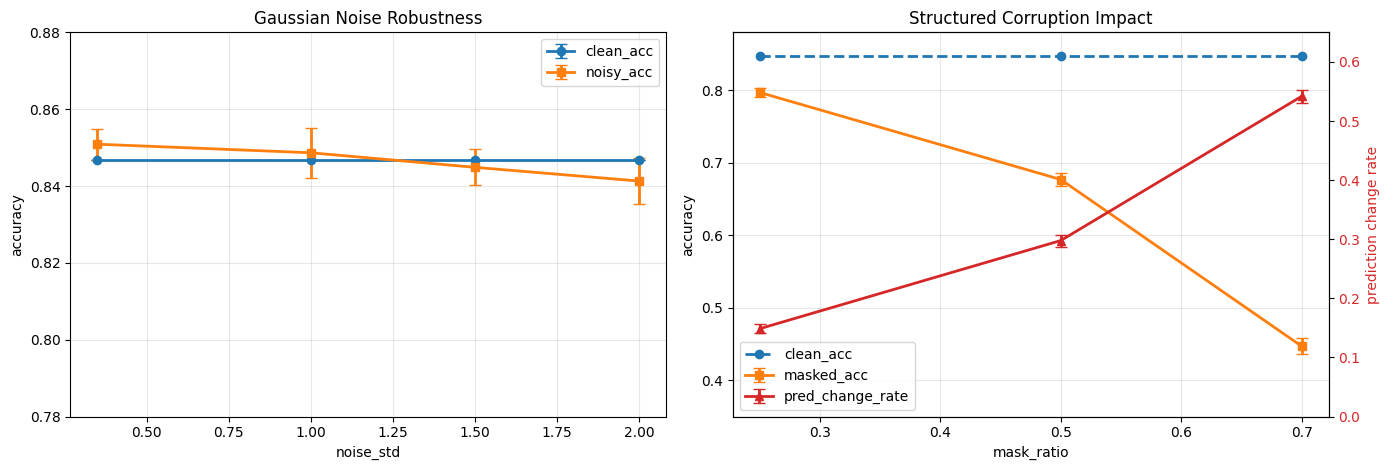

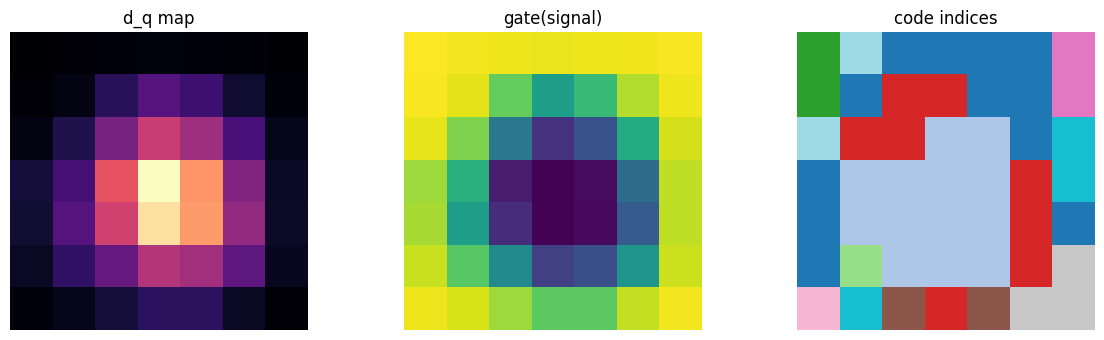

Debug: {'perplexity': 11.110867500305176, 'dq_mean': 0.3509294092655182, 'signal_mean': 0.5550697445869446, 'tau': 0.0420549176633358, 'alpha_softplus': 1.6801313161849976, 'memory_scale': 1.0423290729522705}


In [12]:
# Recreamos el modelo con la nueva definición de la clase para cargar los pesos guardados
model, _, _, _, _ = make_model_and_optimizers(cfg)
model.load_state_dict(best_model_state)

def evaluate_clean_noisy_mc(model, loader, noise_std: float, max_batches: int = 20, repeats: int = 7):
    model.eval()
    clean_scores, noisy_scores = [], []

    for rep in range(repeats):
        torch.manual_seed(1234 + rep)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(1234 + rep)

        clean_correct = 0
        noisy_correct = 0
        total = 0

        with torch.no_grad():
            for bi, (x, y) in enumerate(loader):
                if bi >= max_batches:
                    break
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                logits_clean, _, _ = model(x, feature_noise_std=0.0)
                logits_noisy, _, _ = model(x, feature_noise_std=noise_std)

                clean_correct += (logits_clean.argmax(1) == y).sum().item()
                noisy_correct += (logits_noisy.argmax(1) == y).sum().item()
                total += y.size(0)

        clean_scores.append(clean_correct / max(1, total))
        noisy_scores.append(noisy_correct / max(1, total))

    return {
        'clean_mean': float(np.mean(clean_scores)),
        'clean_std': float(np.std(clean_scores)),
        'noisy_mean': float(np.mean(noisy_scores)),
        'noisy_std': float(np.std(noisy_scores)),
    }

def evaluate_with_mask_corruption(model, loader, mask_ratio: float = 0.5, max_batches: int = 20, repeats: int = 7):
    model.eval()
    clean_scores, masked_scores, changed_scores = [], [], []

    for rep in range(repeats):
        torch.manual_seed(2020 + rep)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(2020 + rep)

        clean_correct = 0
        masked_correct = 0
        changed = 0
        total = 0

        with torch.no_grad():
            for bi, (x, y) in enumerate(loader):
                if bi >= max_batches:
                    break
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                logits_clean, _, _, dbg_clean = model(x, feature_noise_std=0.0, return_debug=True)
                clean_feats = dbg_clean['clean_feats']

                b, c, h, w = clean_feats.shape
                keep = (torch.rand(b, c, 1, 1, device=clean_feats.device) > mask_ratio).float()
                masked_feats = clean_feats * keep

                rec_feats, _, dq_map, _, _ = model.vq_vae(masked_feats)
                dq_norm = model._normalize_per_sample(dq_map)
                alpha = F.softplus(model.gate_alpha)
                signal = torch.sigmoid(alpha * (model.gate_tau - dq_norm))
                enhanced_spatial = masked_feats + model.memory_scale * signal * rec_feats
                enhanced = model.feat_norm(model.pool(enhanced_spatial).flatten(1))
                logits_masked = model.classifier(enhanced)

                pred_clean = logits_clean.argmax(1)
                pred_masked = logits_masked.argmax(1)

                clean_correct += (pred_clean == y).sum().item()
                masked_correct += (pred_masked == y).sum().item()
                changed += (pred_clean != pred_masked).sum().item()
                total += y.size(0)

        clean_scores.append(clean_correct / max(1, total))
        masked_scores.append(masked_correct / max(1, total))
        changed_scores.append(changed / max(1, total))

    return {
        'clean_mean': float(np.mean(clean_scores)),
        'clean_std': float(np.std(clean_scores)),
        'masked_mean': float(np.mean(masked_scores)),
        'masked_std': float(np.std(masked_scores)),
        'pred_change_rate_mean': float(np.mean(changed_scores)),
        'pred_change_rate_std': float(np.std(changed_scores)),
    }

# 1) Barrido gaussiano (con incertidumbre)
gaussian_levels = [cfg.feature_noise_std, 1.0, 1.5, 2.0]
gaussian_results = []

print('=== Gaussian noise sweep (MC) ===')
for ns in gaussian_levels:
    m = evaluate_clean_noisy_mc(model, testloader, noise_std=ns, max_batches=10, repeats=7)
    gaussian_results.append({'noise_std': ns, **m})
    print(f"noise_std={ns:>4}: clean={m['clean_mean']:.4f}±{m['clean_std']:.4f} | noisy={m['noisy_mean']:.4f}±{m['noisy_std']:.4f}")

# 2) Corrupción estructurada (con incertidumbre)
mask_levels = [0.25, 0.50, 0.70]
mask_results = []

print('\n=== Structured corruption (channel masking) ===')
for ratio in mask_levels:
    r = evaluate_with_mask_corruption(model, testloader, mask_ratio=ratio, max_batches=10, repeats=7)
    mask_results.append({'mask_ratio': ratio, **r})
    print(f"mask_ratio={ratio:.2f}: clean={r['clean_mean']:.4f}±{r['clean_std']:.4f} | masked={r['masked_mean']:.4f}±{r['masked_std']:.4f} | changed={r['pred_change_rate_mean']:.4f}±{r['pred_change_rate_std']:.4f}")

# =========================
# VISUALIZACIONES DE INSIGHT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Gráfico A: accuracy clean vs noisy con barras de error (gaussian noise)
x_g = np.array([d['noise_std'] for d in gaussian_results], dtype=float)
y_clean_g = np.array([d['clean_mean'] for d in gaussian_results], dtype=float)
y_clean_g_std = np.array([d['clean_std'] for d in gaussian_results], dtype=float)
y_noisy_g = np.array([d['noisy_mean'] for d in gaussian_results], dtype=float)
y_noisy_g_std = np.array([d['noisy_std'] for d in gaussian_results], dtype=float)

a0 = axes[0]
a0.errorbar(x_g, y_clean_g, yerr=y_clean_g_std, marker='o', capsize=4, linewidth=2, label='clean_acc')
a0.errorbar(x_g, y_noisy_g, yerr=y_noisy_g_std, marker='s', capsize=4, linewidth=2, label='noisy_acc')
a0.set_title('Gaussian Noise Robustness')
a0.set_xlabel('noise_std')
a0.set_ylabel('accuracy')
a0.set_ylim(0.78, 0.88)
a0.grid(alpha=0.3)
a0.legend()

# Gráfico B: corrupción estructurada (accuracy vs cambio de predicción)
x_m = np.array([d['mask_ratio'] for d in mask_results], dtype=float)
y_clean_m = np.array([d['clean_mean'] for d in mask_results], dtype=float)
y_mask_m = np.array([d['masked_mean'] for d in mask_results], dtype=float)
y_mask_m_std = np.array([d['masked_std'] for d in mask_results], dtype=float)
y_change = np.array([d['pred_change_rate_mean'] for d in mask_results], dtype=float)
y_change_std = np.array([d['pred_change_rate_std'] for d in mask_results], dtype=float)

a1 = axes[1]
a1.errorbar(x_m, y_clean_m, marker='o', linestyle='--', linewidth=2, label='clean_acc')
a1.errorbar(x_m, y_mask_m, yerr=y_mask_m_std, marker='s', capsize=4, linewidth=2, label='masked_acc')
a1.set_title('Structured Corruption Impact')
a1.set_xlabel('mask_ratio')
a1.set_ylabel('accuracy')
a1.set_ylim(0.35, 0.88)
a1.grid(alpha=0.3)

ax2 = a1.twinx()
ax2.errorbar(x_m, y_change, yerr=y_change_std, marker='^', capsize=4, linewidth=2, color='tab:red', label='pred_change_rate')
ax2.set_ylabel('prediction change rate', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0.0, 0.65)

# Leyenda combinada (subgráfico derecho)
lines_1, labels_1 = a1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
a1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left')

plt.tight_layout()
plt.show()

# inspección visual de un sample
model.eval()
with torch.no_grad():
    x, y = next(iter(testloader))
    x = x[:1].to(device)
    _, _, _, dbg = model(x, feature_noise_std=cfg.feature_noise_std, return_debug=True)

    dq = dbg['dq_map'][0, 0].detach().cpu().numpy()
    gate = dbg['signal'][0, 0].detach().cpu().numpy()
    code = dbg['code_map'][0].detach().cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
ax[0].imshow(dq, cmap='magma'); ax[0].set_title('d_q map'); ax[0].axis('off')
ax[1].imshow(gate, cmap='viridis'); ax[1].set_title('gate(signal)'); ax[1].axis('off')
ax[2].imshow(code, cmap='tab20'); ax[2].set_title('code indices'); ax[2].axis('off')
plt.tight_layout()
plt.show()

print('Debug:', {
    'perplexity': float(dbg['perplexity'].item()),
    'dq_mean': float(dbg['dq_map'].mean().item()),
    'signal_mean': float(dbg['signal'].mean().item()),
    'tau': float(model.gate_tau.item()),
    'alpha_softplus': float(F.softplus(model.gate_alpha).item()),
    'memory_scale': float(model.memory_scale.item()),
})

## 8) DeMemte Project Dashboard (visual summary)

Esta sección resume de forma visual:
- Curvas de entrenamiento (fases P1 y P2).
- Resultados por fold (CV).
- Robustez clean vs noisy por clase.
- Matrices de confusión (clean y noisy).
- Dinámica interna del módulo de memoria (d_q, gate, codebook y confianza).

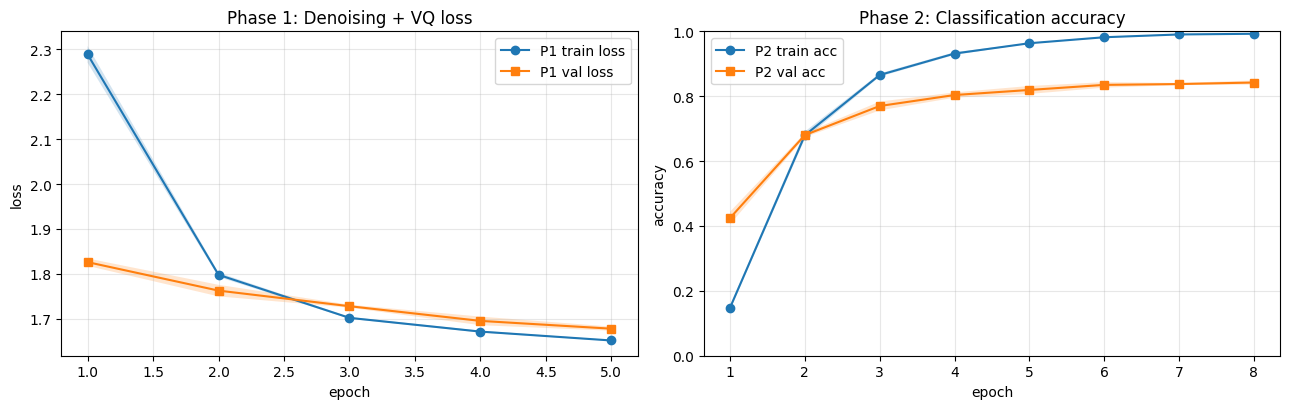

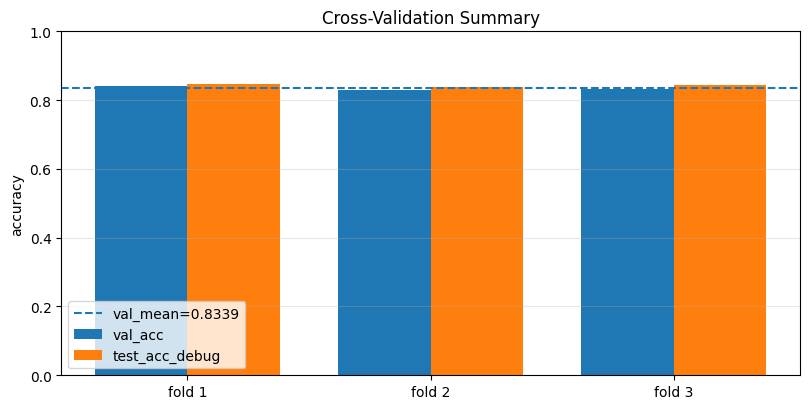

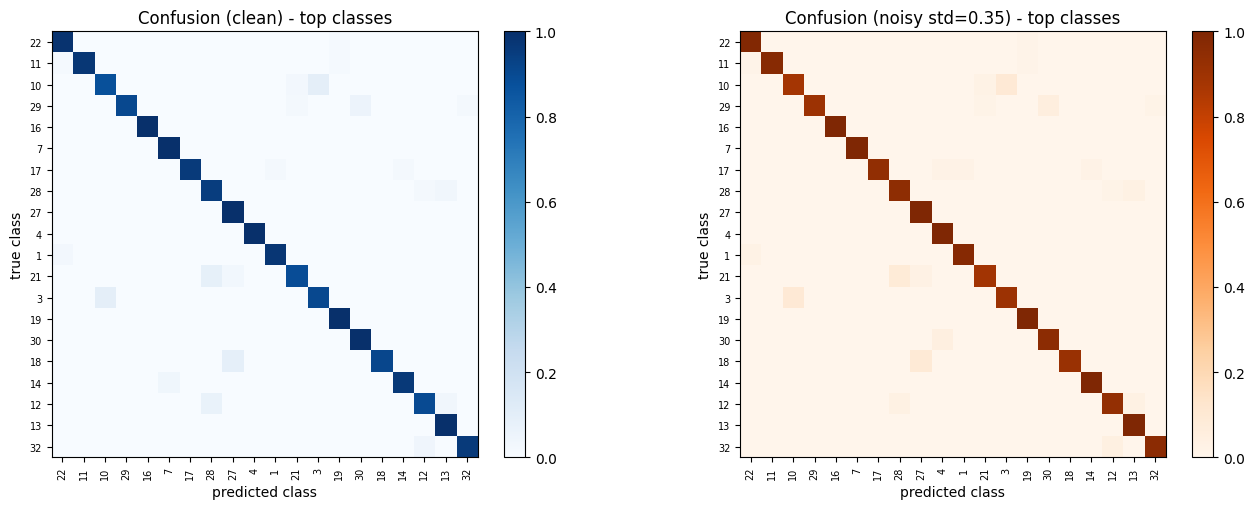

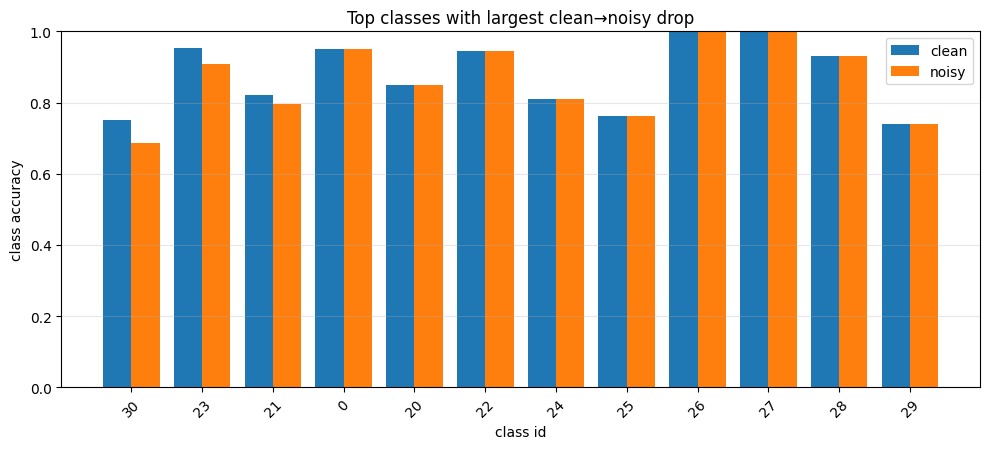

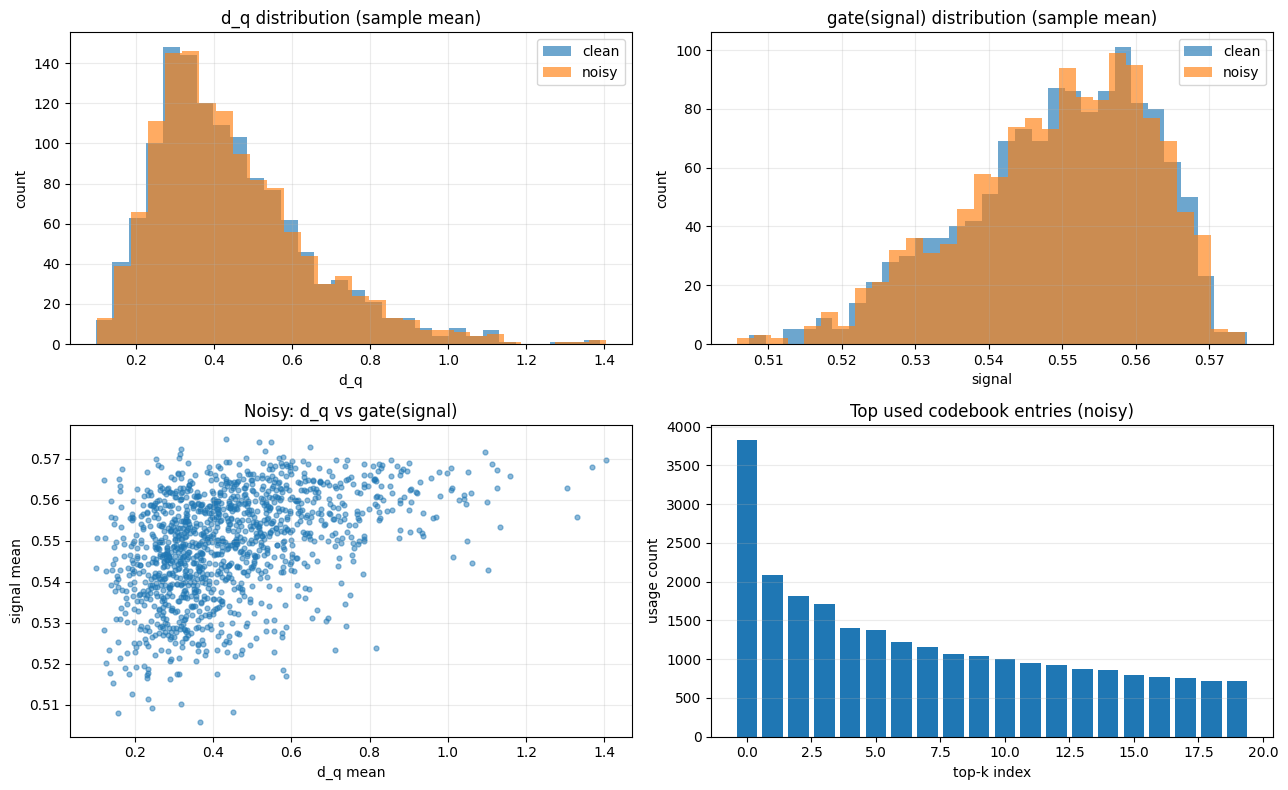

=== Dashboard Key Numbers ===
clean_acc: 0.8523
noisy_acc(std=0.35): 0.8508
prediction_change_rate(clean->noisy): 0.0094
confidence_clean_mean: 0.6290
confidence_noisy_mean: 0.6275
perplexity_clean_mean: 47.1368
perplexity_noisy_mean: 47.7484


In [13]:
from sklearn.metrics import confusion_matrix

def _series_with_nan(hist_list, key):
    return np.array([h.get(key, np.nan) for h in hist_list], dtype=float)

def _stack_histories(fold_results, phase_key, metric_key):
    series = []
    for fr in fold_results:
        hist = fr['history'][phase_key]
        values = _series_with_nan(hist, metric_key)
        series.append(values)
    max_len = max(len(s) for s in series)
    out = np.full((len(series), max_len), np.nan, dtype=float)
    for i, s in enumerate(series):
        out[i, :len(s)] = s
    return out

p1_train_loss = _stack_histories(fold_results, 'p1_train', 'loss')
p1_val_loss = _stack_histories(fold_results, 'p1_val', 'loss')
p2_train_acc = _stack_histories(fold_results, 'p2_train', 'acc')
p2_val_acc = _stack_histories(fold_results, 'p2_val', 'acc')

def _mean_std(arr2d):
    return np.nanmean(arr2d, axis=0), np.nanstd(arr2d, axis=0)

p1_tr_m, p1_tr_s = _mean_std(p1_train_loss)
p1_va_m, p1_va_s = _mean_std(p1_val_loss)
p2_tr_m, p2_tr_s = _mean_std(p2_train_acc)
p2_va_m, p2_va_s = _mean_std(p2_val_acc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ep1 = np.arange(1, len(p1_tr_m) + 1)
axes[0].plot(ep1, p1_tr_m, marker='o', label='P1 train loss')
axes[0].fill_between(ep1, p1_tr_m - p1_tr_s, p1_tr_m + p1_tr_s, alpha=0.2)
axes[0].plot(ep1, p1_va_m, marker='s', label='P1 val loss')
axes[0].fill_between(ep1, p1_va_m - p1_va_s, p1_va_m + p1_va_s, alpha=0.2)
axes[0].set_title('Phase 1: Denoising + VQ loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

ep2 = np.arange(1, len(p2_tr_m) + 1)
axes[1].plot(ep2, p2_tr_m, marker='o', label='P2 train acc')
axes[1].fill_between(ep2, p2_tr_m - p2_tr_s, p2_tr_m + p2_tr_s, alpha=0.2)
axes[1].plot(ep2, p2_va_m, marker='s', label='P2 val acc')
axes[1].fill_between(ep2, p2_va_m - p2_va_s, p2_va_m + p2_va_s, alpha=0.2)
axes[1].set_title('Phase 2: Classification accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

fold_ids = [fr['fold'] for fr in fold_results]
val_accs = np.array([fr['val_acc'] for fr in fold_results], dtype=float)
test_accs = np.array([fr['test_acc_debug'] for fr in fold_results], dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(8.2, 4.2))
idx = np.arange(len(fold_ids))
bar_w = 0.38
ax.bar(idx - bar_w/2, val_accs, width=bar_w, label='val_acc')
ax.bar(idx + bar_w/2, test_accs, width=bar_w, label='test_acc_debug')
ax.axhline(np.mean(val_accs), linestyle='--', linewidth=1.5, label=f"val_mean={np.mean(val_accs):.4f}")
ax.set_xticks(idx)
ax.set_xticklabels([f'fold {f}' for f in fold_ids])
ax.set_ylim(0.0, 1.0)
ax.set_title('Cross-Validation Summary')
ax.set_ylabel('accuracy')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

model.eval()
y_true, y_pred_clean, y_pred_noisy = [], [], []
conf_clean, conf_noisy = [], []
dq_clean_all, dq_noisy_all = [], []
sig_clean_all, sig_noisy_all = [], []
perp_clean, perp_noisy = [], []
code_indices_noisy = []

with torch.no_grad():
    for bi, (x, y) in enumerate(testloader):
        if bi >= 20:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits_c, _, _, dbg_c = model(x, feature_noise_std=0.0, return_debug=True)
        logits_n, _, _, dbg_n = model(x, feature_noise_std=cfg.feature_noise_std, return_debug=True)

        prob_c = torch.softmax(logits_c, dim=1).max(dim=1).values
        prob_n = torch.softmax(logits_n, dim=1).max(dim=1).values

        y_true.extend(y.cpu().tolist())
        y_pred_clean.extend(logits_c.argmax(dim=1).cpu().tolist())
        y_pred_noisy.extend(logits_n.argmax(dim=1).cpu().tolist())
        conf_clean.extend(prob_c.cpu().tolist())
        conf_noisy.extend(prob_n.cpu().tolist())

        dq_clean_all.extend(dbg_c['dq_map'].mean(dim=(1,2,3)).cpu().tolist())
        dq_noisy_all.extend(dbg_n['dq_map'].mean(dim=(1,2,3)).cpu().tolist())
        sig_clean_all.extend(dbg_c['signal'].mean(dim=(1,2,3)).cpu().tolist())
        sig_noisy_all.extend(dbg_n['signal'].mean(dim=(1,2,3)).cpu().tolist())
        perp_clean.append(float(dbg_c['perplexity'].item()))
        perp_noisy.append(float(dbg_n['perplexity'].item()))
        code_indices_noisy.extend(dbg_n['code_map'].reshape(-1).cpu().tolist())

y_true = np.array(y_true)
y_pred_clean = np.array(y_pred_clean)
y_pred_noisy = np.array(y_pred_noisy)
conf_clean = np.array(conf_clean)
conf_noisy = np.array(conf_noisy)
dq_clean_all = np.array(dq_clean_all)
dq_noisy_all = np.array(dq_noisy_all)
sig_clean_all = np.array(sig_clean_all)
sig_noisy_all = np.array(sig_noisy_all)
perp_clean = np.array(perp_clean)
perp_noisy = np.array(perp_noisy)
code_indices_noisy = np.array(code_indices_noisy)

classes_seen, counts_seen = np.unique(y_true, return_counts=True)
classes_top = classes_seen[np.argsort(-counts_seen)[:20]]

cm_clean = confusion_matrix(y_true, y_pred_clean, labels=classes_top, normalize='true')
cm_noisy = confusion_matrix(y_true, y_pred_noisy, labels=classes_top, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
im0 = axes[0].imshow(cm_clean, vmin=0.0, vmax=1.0, cmap='Blues')
axes[0].set_title('Confusion (clean) - top classes')
axes[0].set_xlabel('predicted class')
axes[0].set_ylabel('true class')
axes[0].set_xticks(range(len(classes_top)))
axes[0].set_yticks(range(len(classes_top)))
axes[0].set_xticklabels(classes_top, rotation=90, fontsize=7)
axes[0].set_yticklabels(classes_top, fontsize=7)

im1 = axes[1].imshow(cm_noisy, vmin=0.0, vmax=1.0, cmap='Oranges')
axes[1].set_title(f'Confusion (noisy std={cfg.feature_noise_std}) - top classes')
axes[1].set_xlabel('predicted class')
axes[1].set_ylabel('true class')
axes[1].set_xticks(range(len(classes_top)))
axes[1].set_yticks(range(len(classes_top)))
axes[1].set_xticklabels(classes_top, rotation=90, fontsize=7)
axes[1].set_yticklabels(classes_top, fontsize=7)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

num_classes = cfg.num_classes
class_total = np.bincount(y_true, minlength=num_classes)
class_hit_clean = np.bincount(y_true[y_true == y_pred_clean], minlength=num_classes)
class_hit_noisy = np.bincount(y_true[y_true == y_pred_noisy], minlength=num_classes)

valid_cls = np.where(class_total > 0)[0]
acc_clean_cls = np.zeros(num_classes)
acc_noisy_cls = np.zeros(num_classes)
acc_clean_cls[valid_cls] = class_hit_clean[valid_cls] / class_total[valid_cls]
acc_noisy_cls[valid_cls] = class_hit_noisy[valid_cls] / class_total[valid_cls]
drop_cls = acc_clean_cls - acc_noisy_cls

top_drop = valid_cls[np.argsort(-drop_cls[valid_cls])[:12]]

fig, ax = plt.subplots(1, 1, figsize=(10, 4.6))
xx = np.arange(len(top_drop))
ax.bar(xx - 0.2, acc_clean_cls[top_drop], width=0.4, label='clean')
ax.bar(xx + 0.2, acc_noisy_cls[top_drop], width=0.4, label='noisy')
ax.set_xticks(xx)
ax.set_xticklabels([str(c) for c in top_drop], rotation=45)
ax.set_title('Top classes with largest clean→noisy drop')
ax.set_xlabel('class id')
ax.set_ylabel('class accuracy')
ax.set_ylim(0.0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].hist(dq_clean_all, bins=30, alpha=0.65, label='clean')
axes[0,0].hist(dq_noisy_all, bins=30, alpha=0.65, label='noisy')
axes[0,0].set_title('d_q distribution (sample mean)')
axes[0,0].set_xlabel('d_q')
axes[0,0].set_ylabel('count')
axes[0,0].legend()
axes[0,0].grid(alpha=0.25)

axes[0,1].hist(sig_clean_all, bins=30, alpha=0.65, label='clean')
axes[0,1].hist(sig_noisy_all, bins=30, alpha=0.65, label='noisy')
axes[0,1].set_title('gate(signal) distribution (sample mean)')
axes[0,1].set_xlabel('signal')
axes[0,1].set_ylabel('count')
axes[0,1].legend()
axes[0,1].grid(alpha=0.25)

axes[1,0].scatter(dq_noisy_all, sig_noisy_all, s=12, alpha=0.5)
axes[1,0].set_title('Noisy: d_q vs gate(signal)')
axes[1,0].set_xlabel('d_q mean')
axes[1,0].set_ylabel('signal mean')
axes[1,0].grid(alpha=0.25)

code_count = np.bincount(code_indices_noisy, minlength=cfg.num_embeddings)
topk = min(20, cfg.num_embeddings)
top_idx = np.argsort(-code_count)[:topk]
axes[1,1].bar(np.arange(topk), code_count[top_idx])
axes[1,1].set_title('Top used codebook entries (noisy)')
axes[1,1].set_xlabel('top-k index')
axes[1,1].set_ylabel('usage count')
axes[1,1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

changed_rate = float(np.mean(y_pred_clean != y_pred_noisy))
print('=== Dashboard Key Numbers ===')
print(f'clean_acc: {float(np.mean(y_pred_clean == y_true)):.4f}')
print(f'noisy_acc(std={cfg.feature_noise_std}): {float(np.mean(y_pred_noisy == y_true)):.4f}')
print(f'prediction_change_rate(clean->noisy): {changed_rate:.4f}')
print(f'confidence_clean_mean: {float(np.mean(conf_clean)):.4f}')
print(f'confidence_noisy_mean: {float(np.mean(conf_noisy)):.4f}')
print(f'perplexity_clean_mean: {float(np.mean(perp_clean)):.4f}')
print(f'perplexity_noisy_mean: {float(np.mean(perp_noisy)):.4f}')

In [8]:
model.eval()
with torch.no_grad():
    x, y = next(iter(testloader))
    x = x[:4].to(device)
    logits_c, _, _, dbg_c = model(x, feature_noise_std=0.0, return_debug=True)
    logits_n, _, _, dbg_n = model(x, feature_noise_std=1.0, return_debug=True)
    
    print("Clean vs Noisy Features max diff:", (dbg_c['noisy_feats'] - dbg_n['noisy_feats']).abs().max().item())
    print("Clean vs Noisy Logits max diff:", (logits_c - logits_n).abs().max().item())
    print("Clean vs Noisy Argmax same:", (logits_c.argmax(1) == logits_n.argmax(1)).sum().item(), "/", 4)


Clean vs Noisy Features max diff: 4.254656791687012
Clean vs Noisy Logits max diff: 0.5982944965362549
Clean vs Noisy Argmax same: 4 / 4


In [9]:
def evaluate_clean_noisy_mc(model, loader, noise_std: float, max_batches: int = 20, repeats: int = 5):
    model.eval()
    clean_scores, noisy_scores = [], []

    for rep in range(repeats):
        torch.manual_seed(1234 + rep)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(1234 + rep)

        clean_correct = 0
        noisy_correct = 0
        total = 0

        with torch.no_grad():
            for bi, (x, y) in enumerate(loader):
                if bi >= max_batches:
                    break
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                logits_clean, _, _ = model(x, feature_noise_std=0.0)
                logits_noisy, _, _ = model(x, feature_noise_std=noise_std)

                clean_correct += (logits_clean.argmax(1) == y).sum().item()
                noisy_correct += (logits_noisy.argmax(1) == y).sum().item()
                total += y.size(0)

        clean_scores.append(clean_correct / max(1, total))
        noisy_scores.append(noisy_correct / max(1, total))

    return {
        'clean_mean': float(np.mean(clean_scores)),
        'clean_std': float(np.std(clean_scores)),
        'noisy_mean': float(np.mean(noisy_scores)),
        'noisy_std': float(np.std(noisy_scores)),
    }

for ns in [0.35, 0.5, 0.75, 1.0, 1.5, 2.0]:
    m = evaluate_clean_noisy_mc(model, testloader, noise_std=ns, max_batches=10, repeats=7)
    print(f"noise_std={ns:>4}: clean={m['clean_mean']:.4f}±{m['clean_std']:.4f} | noisy={m['noisy_mean']:.4f}±{m['noisy_std']:.4f}")

noise_std=0.35: clean=0.8469±0.0000 | noisy=0.8509±0.0040
noise_std= 0.5: clean=0.8469±0.0000 | noisy=0.8511±0.0041
noise_std=0.75: clean=0.8469±0.0000 | noisy=0.8498±0.0063
noise_std= 1.0: clean=0.8469±0.0000 | noisy=0.8487±0.0065
noise_std= 1.5: clean=0.8469±0.0000 | noisy=0.8449±0.0047
noise_std= 2.0: clean=0.8469±0.0000 | noisy=0.8413±0.0061


In [10]:
def evaluate_with_mask_corruption(model, loader, mask_ratio: float = 0.5, max_batches: int = 20, repeats: int = 5):
    model.eval()
    clean_scores, masked_scores, changed_scores = [], [], []

    for rep in range(repeats):
        torch.manual_seed(2020 + rep)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(2020 + rep)

        clean_correct = 0
        masked_correct = 0
        changed = 0
        total = 0

        with torch.no_grad():
            for bi, (x, y) in enumerate(loader):
                if bi >= max_batches:
                    break
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                # Logits clean
                logits_clean, _, _, dbg_clean = model(x, feature_noise_std=0.0, return_debug=True)

                # Corrupción estructurada en feature-space: apaga canales completos
                clean_feats = dbg_clean['clean_feats']
                b, c, h, w = clean_feats.shape
                keep = (torch.rand(b, c, 1, 1, device=clean_feats.device) > mask_ratio).float()
                masked_feats = clean_feats * keep

                # Recorremos SOLO VQ+head con los features ya corruptos
                rec_feats, _, dq_map, _, _ = model.vq_vae(masked_feats)
                dq_norm = model._normalize_per_sample(dq_map)
                alpha = F.softplus(model.gate_alpha)
                signal = torch.sigmoid(alpha * (model.gate_tau - dq_norm))
                enhanced_spatial = masked_feats + model.memory_scale * signal * rec_feats
                enhanced = model.feat_norm(model.pool(enhanced_spatial).flatten(1))
                logits_masked = model.classifier(enhanced)

                pred_clean = logits_clean.argmax(1)
                pred_masked = logits_masked.argmax(1)

                clean_correct += (pred_clean == y).sum().item()
                masked_correct += (pred_masked == y).sum().item()
                changed += (pred_clean != pred_masked).sum().item()
                total += y.size(0)

        clean_scores.append(clean_correct / max(1, total))
        masked_scores.append(masked_correct / max(1, total))
        changed_scores.append(changed / max(1, total))

    return {
        'clean_mean': float(np.mean(clean_scores)),
        'clean_std': float(np.std(clean_scores)),
        'masked_mean': float(np.mean(masked_scores)),
        'masked_std': float(np.std(masked_scores)),
        'pred_change_rate_mean': float(np.mean(changed_scores)),
        'pred_change_rate_std': float(np.std(changed_scores)),
    }

for ratio in [0.25, 0.5, 0.7]:
    r = evaluate_with_mask_corruption(model, testloader, mask_ratio=ratio, max_batches=10, repeats=7)
    print(f"mask_ratio={ratio:.2f}: clean={r['clean_mean']:.4f}±{r['clean_std']:.4f} | masked={r['masked_mean']:.4f}±{r['masked_std']:.4f} | changed={r['pred_change_rate_mean']:.4f}±{r['pred_change_rate_std']:.4f}")

mask_ratio=0.25: clean=0.8469±0.0000 | masked=0.7971±0.0061 | changed=0.1487±0.0081
mask_ratio=0.50: clean=0.8469±0.0000 | masked=0.6770±0.0086 | changed=0.2978±0.0101
mask_ratio=0.70: clean=0.8469±0.0000 | masked=0.4471±0.0110 | changed=0.5417±0.0109
